In [1]:
from hydra import initialize, compose
import pandas as pd
from tools.helpers import simple_sample_display
from tools.scoring_tools import max_accuracy
from tools.tools import make_human_readable
from methods.varlingam import run_varlingam

### Trivial example for any causal discovery method in the cd_zoo

In [2]:
X = pd.read_csv("sample_datasets/split_format/0_data.csv", index_col=0)
Y = pd.read_csv("sample_datasets/split_format/0_label.csv", index_col=0)

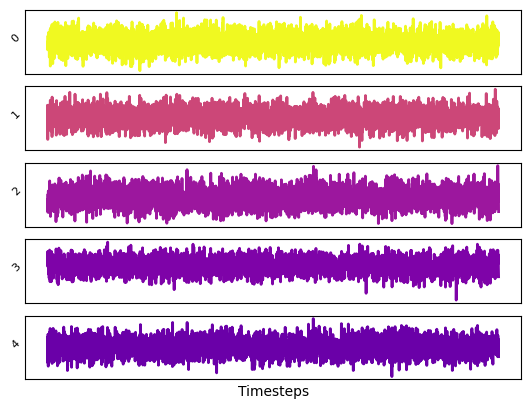

In [3]:
simple_sample_display(X)

In [4]:
# load hydra config for method. You can arbitrarily change the parameters after loading
with initialize(config_path="config/method",version_base="1.2"):
    cfg = compose(config_name="varlingam.yaml")

In [5]:
# Run the method by providing data(X) and config (cfg)
# Returns Lagged effect (Effect x Cause x Lag) and Instantaneous effect (Effect x Cause)    
Y_,Y0 = run_varlingam(X,cfg)

In [6]:
# Transfer the predictions to a human readable format if necessary
make_human_readable(Y_.max(axis=2),Y)

Cause                                       
                 0         1        2         3         4
Effect 0  0.000000  0.043691  0.00000  0.000000  0.000000
       1  0.317793  0.000000  0.00000  0.000000  0.000000
       2  0.000000  0.000000  0.00000  0.399691  0.000000
       3  0.315604  0.000000  0.00000  0.000000  0.438449
       4  0.000000  0.000000  0.37128  0.000000  0.000000

In [7]:
# Calculate performance metrics.
threshold, metric = max_accuracy(Y,Y_.max(axis=2))
metric

1.0

#### 💡 For more advanced functionality, please refer to "example_run.py" and "benchmark.py" 💡